# RetailIQ - Exploratory Data Analysis

Explores the cleaned dataset to answer the business questions: top products, regional/store performance, customer segments, profit & discount analysis, and seasonality. Mirrors `analytics/analysis.py`.

## 1. Load cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/cleaned/retail_sales_cleaned.csv", parse_dates=["Date"])
df.head()

,Order_ID,Date,Year,Month,Month_Name,Quarter,Weekday,Is_Weekend,Customer_ID,Customer_Name,...,Sub_Category,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Margin_Pct,Supplier,Payment_Method
0,ORD017504,2024-05-05,2024,5,May,2,Sunday,True,CUST00396,Karan Agarwal,...,Office Supplies,1,1184.75,0.00,1184.75,805.63,379.12,32.0,OfficeMart Supplies,Cash on Delivery
1,ORD046116,2025-11-04,2025,11,Nov,4,Tuesday,False,CUST03696,Vihaan Gupta,...,Storage,1,12888.61,0.15,10955.32,8764.25,2191.07,20.0,KitchenCraft Suppliers,UPI
2,ORD059784,2024-04-14,2024,4,Apr,2,Sunday,True,CUST00665,Tanya Das,...,Beverages,3,587.75,0.00,1763.25,1199.01,564.24,32.0,DailyNeeds Distributors,Debit Card
3,ORD011462,2024-07-04,2024,7,Jul,3,Thursday,False,CUST01154,Kabir Joshi,...,Office Supplies,1,168.57,0.00,168.57,114.63,53.94,32.0,PageTurner Distributors,UPI
4,ORD050030,2024-10-13,2024,10,Oct,4,Sunday,True,CUST00655,Rahul Gupta,...,Snacks,1,595.62,0.00,595.62,405.02,190.60,32.0,FreshMart Supply Chain,Credit Card


## 2. High level numbers

In [2]:
print(f"Rows: {len(df):,}")
print(f"Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Total Revenue: Rs.{df['Sales'].sum():,.0f}")
print(f"Total Profit : Rs.{df['Profit'].sum():,.0f}")
print(f"Total Orders : {df['Order_ID'].nunique():,}")

Rows: 59,710
Date range: 2023-01-01 -> 2025-12-30
Total Revenue: Rs.828,048,066
Total Profit : Rs.188,026,353
Total Orders : 59,707


## 3. Monthly sales trend

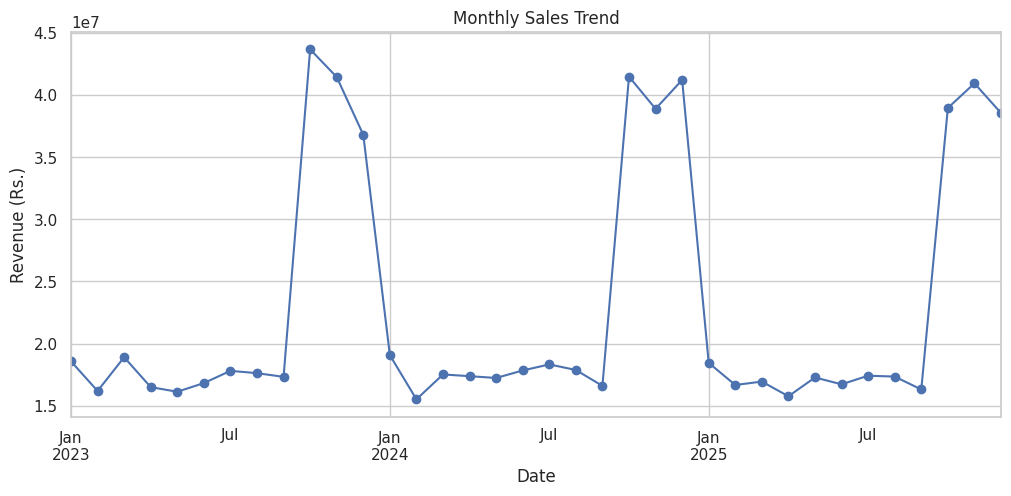

In [3]:
monthly = df.groupby(df["Date"].dt.to_period("M"))["Sales"].sum()
monthly.plot(figsize=(12,5), marker="o", title="Monthly Sales Trend")
plt.ylabel("Revenue (Rs.)")
plt.show()

## 4. Revenue by category & region

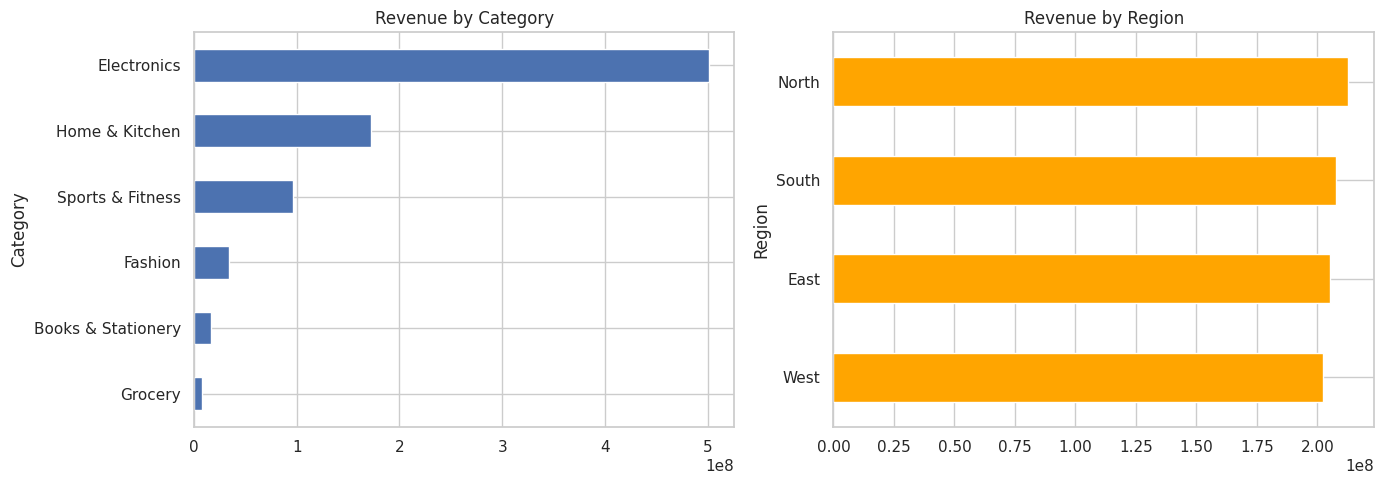

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df.groupby("Category")["Sales"].sum().sort_values().plot(kind="barh", ax=axes[0], title="Revenue by Category")
df.groupby("Region")["Sales"].sum().sort_values().plot(kind="barh", ax=axes[1], title="Revenue by Region", color="orange")
plt.tight_layout()
plt.show()

## 5. Top & worst products

In [5]:
top10 = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)
worst10 = df.groupby("Product_Name")["Sales"].sum().sort_values().head(10)
print("Top 10:\n", top10)
print("\nWorst 10:\n", worst10)

Top 10:
 Product_Name
Mobiles Electronics Model-23         12782561.65
Laptops Electronics Model-10         12715736.30
Headphones Electronics Model-75      12711711.35
Headphones Electronics Model-21      12375320.67
Cameras Electronics Model-12         12264292.19
Mobiles Electronics Model-80         11959378.77
Cameras Electronics Model-68         11955692.74
Laptops Electronics Model-79         11763835.82
Mobiles Electronics Model-48         11501376.06
Smartwatches Electronics Model-33    11265712.05
Name: Sales, dtype: float64

Worst 10:
 Product_Name
Staples Grocery Model-326      3833.28
Office Books Model-461         9765.27
Academic Books Model-464      10075.76
Snacks Grocery Model-252      10089.52
Snacks Grocery Model-280      14496.53
Office Books Model-426        16265.02
Personal Grocery Model-319    18416.68
Staples Grocery Model-277     18874.35
Personal Grocery Model-264    21708.51
Personal Grocery Model-276    23077.64
Name: Sales, dtype: float64


## 6. Store comparison

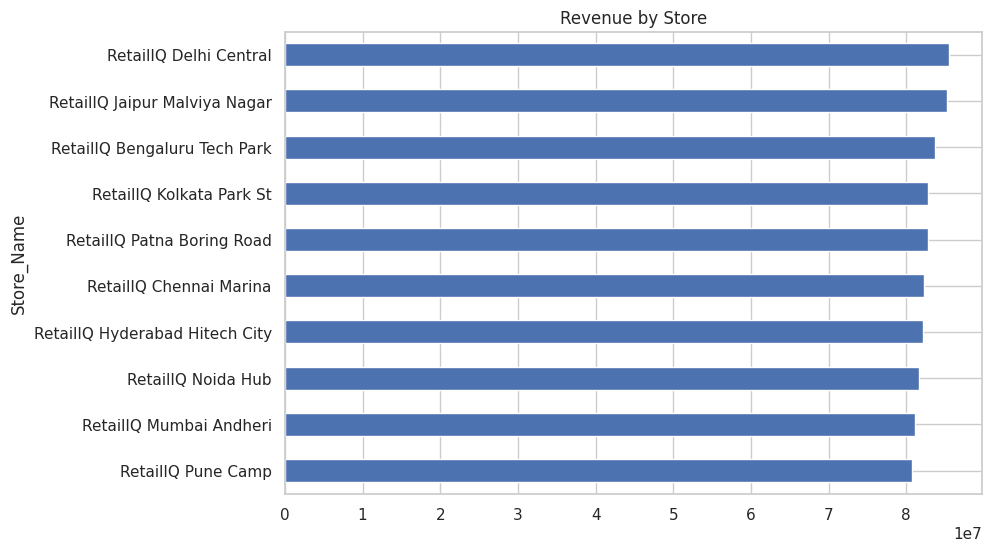

In [6]:
df.groupby("Store_Name")["Sales"].sum().sort_values().plot(kind="barh", figsize=(9,6), title="Revenue by Store")
plt.show()

## 7. Customer segmentation (spend distribution)

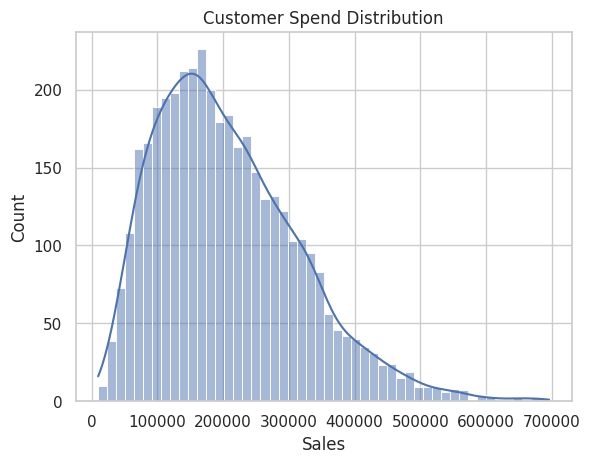

In [7]:
cust_spend = df.groupby("Customer_ID")["Sales"].sum()
sns.histplot(cust_spend, bins=50, kde=True)
plt.title("Customer Spend Distribution")
plt.show()

## 8. Profit distribution & discount impact

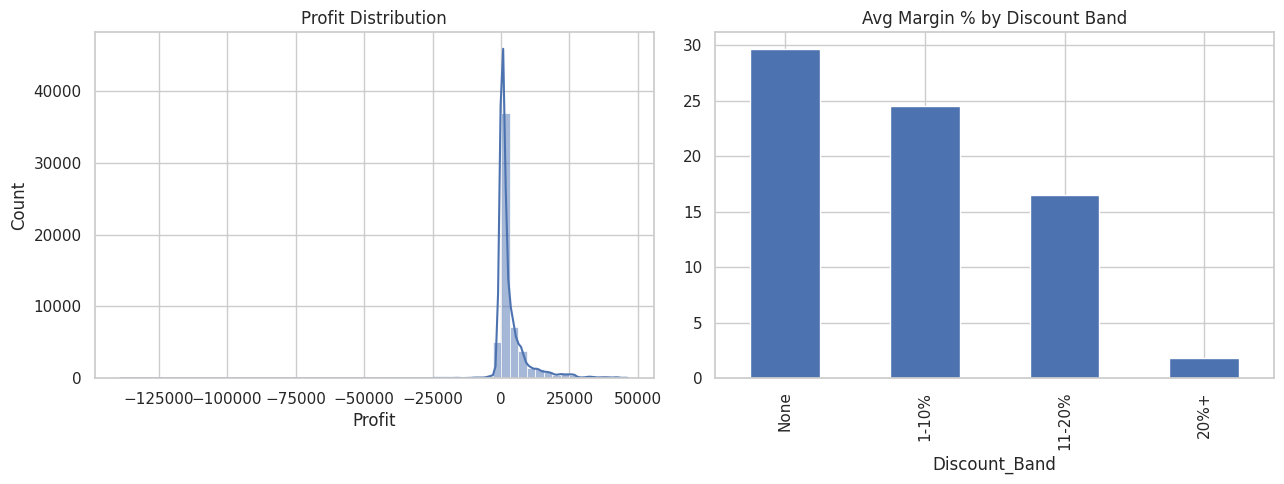

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(df["Profit"], bins=60, ax=axes[0], kde=True)
axes[0].set_title("Profit Distribution")

df["Discount_Band"] = pd.cut(df["Discount"], bins=[-0.01,0,0.1,0.2,1], labels=["None","1-10%","11-20%","20%+"])
df.groupby("Discount_Band", observed=True)["Margin_Pct"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Avg Margin % by Discount Band")
plt.tight_layout()
plt.show()

## 9. Correlation heatmap

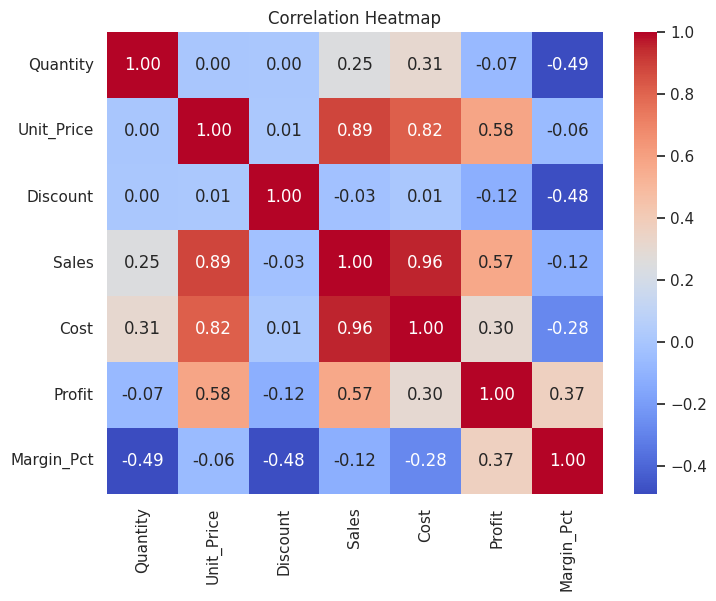

In [9]:
numeric_cols = ["Quantity","Unit_Price","Discount","Sales","Cost","Profit","Margin_Pct"]
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 10. Seasonality

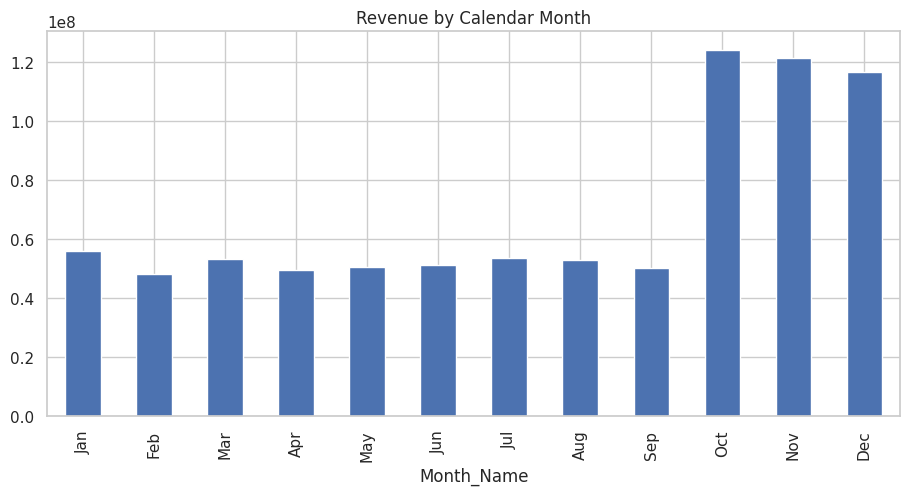

In [10]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
df.groupby("Month_Name")["Sales"].sum().reindex(month_order).plot(kind="bar", figsize=(11,5), title="Revenue by Calendar Month")
plt.show()